In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Загрузка данных

In [24]:
df = pd.read_csv('/home/nursss/Документы/updated_data.csv')
df["time"] = pd.to_datetime(df["time"])
df = df.sort_values("time")

# Список уникальных точек
unique_points = df[["latitude", "longitude"]].drop_duplicates()

# Интерполяция и daily index для каждой точки

In [25]:
processed_dfs = []

for _, row in unique_points.iterrows():
    lat, lon = row["latitude"], row["longitude"]
    df_point = df[(df["latitude"] == lat) & (df["longitude"] == lon)].copy()
    df_point = df_point.set_index("time")

    full_range = pd.date_range(start=df_point.index.min(),
                               end=df_point.index.max(),
                               freq="D")
    df_point = df_point.reindex(full_range)

    # Интерполяция
    df_point["sm_tgt"] = df_point["sm_tgt"].interpolate()
    df_point["sm_aux"] = df_point["sm_aux"].interpolate()
    df_point["clay_content"] = df_point["clay_content"].ffill()
    df_point["sand_content"] = df_point["sand_content"].ffill()
    df_point["silt_content"] = df_point["silt_content"].ffill()

    df_point["latitude"] = lat
    df_point["longitude"] = lon

    processed_dfs.append(df_point)

df_all = pd.concat(processed_dfs)
df_all = df_all.sort_index()
print("Общее количество строк после выравнивания:", len(df_all))


Общее количество строк после выравнивания: 417820


# Создание признаков соседних точек

In [26]:
def add_neighbour_features(df, radius=0.01):
    df_feat = []
    points = df[["latitude", "longitude"]].drop_duplicates()
    for _, row in points.iterrows():
        lat, lon = row["latitude"], row["longitude"]
        df_point = df[(df["latitude"] == lat) & (df["longitude"] == lon)].copy()

        # Находим соседей
        neighbours = df[(np.abs(df["latitude"]-lat)<=radius) & (np.abs(df["longitude"]-lon)<=radius)
                        & ((df["latitude"] != lat) | (df["longitude"] != lon))]
        if len(neighbours) > 0:
            neigh_sm = neighbours.groupby(neighbours.index)["sm_tgt"].mean()
            df_point["sm_tgt_neigh"] = neigh_sm
        else:
            df_point["sm_tgt_neigh"] = df_point["sm_tgt"]  # если соседей нет
        df_feat.append(df_point)
    return pd.concat(df_feat)

df_all_feat = add_neighbour_features(df_all)


# Подготовка данных для LSTM

In [27]:
features = ["sm_tgt", "sm_aux", "clay_content", "sand_content", "silt_content", "sm_tgt_neigh"]
data = df_all_feat[features].values

window = 24

def create_sequences(data, window):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i])
        y.append(data[i, 0])  # sm_tgt
    return np.array(X), np.array(y)

X, y = create_sequences(data, window)
print("X shape:", X.shape, "y shape:", y.shape)


X shape: (417796, 24, 6) y shape: (417796,)


# Разделение на train / val / test без shuffle

In [28]:
train_size = int(0.7 * len(X))
val_size = int(0.85 * len(X))

X_train, X_val, X_test = X[:train_size], X[train_size:val_size], X[val_size:]
y_train, y_val, y_test = y[:train_size], y[train_size:val_size], y[val_size:]

# Масштабирование
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_reshaped = X_train.reshape(-1, X_train.shape[2])
scaler_X.fit(X_train_reshaped)
scaler_y.fit(y_train.reshape(-1,1))

def scale_X(X):
    X_reshaped = X.reshape(-1, X.shape[2])
    X_scaled = scaler_X.transform(X_reshaped)
    return X_scaled.reshape(X.shape)

X_train = scale_X(X_train)
X_val = scale_X(X_val)
X_test = scale_X(X_test)

y_train = scaler_y.transform(y_train.reshape(-1,1))
y_val = scaler_y.transform(y_val.reshape(-1,1))
y_test = scaler_y.transform(y_test.reshape(-1,1))


# LSTM модель

In [32]:
soil_model = Sequential([
    LSTM(32, input_shape=(window, X_train.shape[2])),
    Dropout(0.1),
    Dense(1)
])

soil_model.compile(optimizer="adam", loss="mse", metrics=["mae"])
early_stop = EarlyStopping(patience=5, restore_best_weights=True)

history = soil_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=16,
    callbacks=[early_stop]
)

2026-02-21 13:57:17.928189: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 168455232 exceeds 10% of free system memory.


Epoch 1/30
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 142s 8ms/step - loss: 0.0122 - mae: 0.0809 - val_loss: 0.0111 - val_mae: 0.0770
Epoch 2/30
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 127s 7ms/step - loss: 0.0108 - mae: 0.0758 - val_loss: 0.0107 - val_mae: 0.0749
Epoch 3/30
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 106s 6ms/step - loss: 0.0102 - mae: 0.0737 - val_loss: 0.0100 - val_mae: 0.0718
Epoch 4/30
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 103s 6ms/step - loss: 0.0100 - mae: 0.0728 - val_loss: 0.0101 - val_mae: 0.0730
Epoch 5/30
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 103s 6ms/step - loss: 0.0099 - mae: 0.0723 - val_loss: 0.0098 - val_mae: 0.0712
Epoch 6/30
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 102s 6ms/step - loss: 0.0098 - mae: 0.0720 - val_loss: 0.0097 - val_mae: 0.0712
Epoch 7/30
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 102s 6ms/step - loss: 0.0097 - mae: 0.0717 - val_loss: 0.0097 - val_mae: 0.0707
Epoch 8/30
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 102s 6ms/step - loss: 0.0097 - mae: 0.0714 - val_loss: 0.0096 - val_mae: 0.0695
Epoch 9/

# Оценка модели


In [33]:
y_pred_scaled = soil_model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test)

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
print("MAE:", mae)
print("RMSE:", rmse)

# baseline naive
naive_pred = X_test[:, -1, 0]
naive_pred = scaler_y.inverse_transform(naive_pred.reshape(-1,1))
mae_naive = mean_absolute_error(y_true, naive_pred)
print("MAE LSTM:", mae)
print("MAE Naive:", mae_naive)

1959/1959 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
MAE: 0.03573323244808006
RMSE: 0.055039923989476276
MAE LSTM: 0.03573323244808006
MAE Naive: 0.035822403063666824


# Визуализация

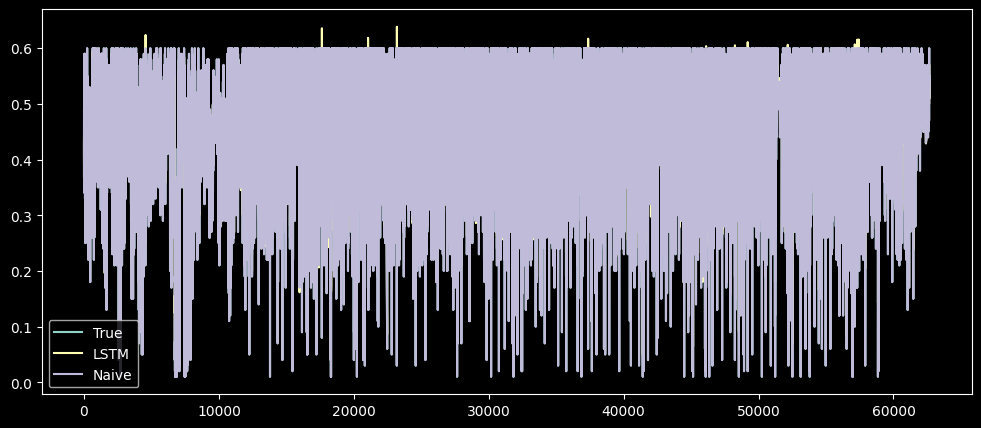

In [34]:
plt.figure(figsize=(12,5))
plt.plot(y_true, label="True")
plt.plot(y_pred, label="LSTM")
plt.plot(naive_pred, label="Naive")
plt.legend()
plt.show()

In [35]:
y_pred

array([[0.43400112],
       [0.36711514],
       [0.42365593],
       ...,
       [0.5305466 ],
       [0.5397549 ],
       [0.542246  ]], shape=(62670, 1), dtype=float32)

In [39]:
def forecast_point(model, df_point, window, scaler_X, scaler_y, n_days=7):
    """
    model      : обученная LSTM
    df_point   : DataFrame с одной точкой, индекс datetime
    window     : длина окна (кол-во прошлых дней)
    scaler_X   : MinMaxScaler для признаков
    scaler_y   : MinMaxScaler для цели
    n_days     : количество дней вперёд для прогноза
    """
    features = ["sm_tgt", "sm_aux", "clay_content", "sand_content", "silt_content", "sm_tgt_neigh"]

    last_window = df_point[features].values[-window:]
    preds = []

    for i in range(n_days):
        X_input = last_window.reshape(1, window, len(features))
        # масштабируем
        X_scaled = X_input.reshape(-1, len(features))
        X_scaled = scaler_X.transform(X_scaled).reshape(1, window, len(features))

        # прогноз
        y_scaled = model.predict(X_scaled, verbose=0)
        y_pred = scaler_y.inverse_transform(y_scaled)[0, 0]
        preds.append(y_pred)

        # обновляем окно для следующего дня
        next_row = last_window[-1].copy()
        next_row[0] = y_pred  # sm_tgt заменяем на прогноз
        last_window = np.vstack([last_window[1:], next_row])

    dates_pred = pd.date_range(start=df_point.index[-1] + pd.Timedelta(days=1), periods=n_days)
    df_forecast = pd.DataFrame({
        "date": dates_pred,
        "sm_tgt_pred": preds
    })
    return df_forecast

In [40]:
# Прогноз на 7 дней вперед для точки lat=54.875, lon=9.125
lat, lon = 54.875, 9.125
df_point = df_all_feat[(df_all_feat["latitude"]==lat) & (df_all_feat["longitude"]==lon)].copy()

df_future = forecast_point(soil_model, df_point, window=24, scaler_X=scaler_X, scaler_y=scaler_y, n_days=7)
print(df_future)

        date  sm_tgt_pred
0 2014-01-01     0.433417
1 2014-01-02     0.431098
2 2014-01-03     0.428385
3 2014-01-04     0.427436
4 2014-01-05     0.432308
5 2014-01-06     0.433965
6 2014-01-07     0.440194
